In [1]:
!pip install torch==2.3.1 torchvision==0.18.1 --index-url https://download.pytorch.org/whl/cu118 -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 839.6/839.6 MB 2.0 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.3/6.3 MB 41.2 MB/s eta 0:00:00:00:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.2/23.2 MB 63.0 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 875.6/875.6 kB 41.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.1/13.1 MB 76.9 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 728.5/728.5 MB 2.4 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 417.9/417.9 MB 4.2 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 168.4/168.4 MB 10.1 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.1/58.1 MB 7.1 MB/s eta 0:00:00:00:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 128.2/128.2 MB 13.4 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.1/204.1 MB 1.9 MB/s eta 0:00:0000:0100:01
     ━━━━━

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 6.0 MB/s eta 0:00:00
Device : cuda
PyTorch: 2.3.1+cu118
Total available train samples: 56788
Train: 4000 | Val: 1000

  Model  : SwinUNet
  Params : 41.39M
  Device : cuda
  Ep 001 | Loss:0.4009 | Dice:0.5976 | IoU:0.4314 | PixAcc:0.9773 | Acc:0.9773 | Prec:0.6385 | Rec:0.5733 | Spec:0.9899
  Ep 010 | Loss:0.1677 | Dice:0.7757 | IoU:0.6370 | PixAcc:0.9864 | Acc:0.9864 | Prec:0.7623 | Rec:0.7939 | Spec:0.9924
  Ep 020 | Loss:0.1480 | Dice:0.7961 | IoU:0.6644 | PixAcc:0.9879 | Acc:0.9879 | Prec:0.7947 | Rec:0.8010 | Spec:0.9937
  Ep 030 | Loss:0.1361 | Dice:0.8064 | IoU:0.6787 | PixAcc:0.9887 | Acc:0.9887 | Prec:0.8161 | Rec:0.8004 | Spec:0.9945
  Ep 040 | Loss:0.1257 | Dice:0.8109 | IoU:0.6851 | PixAcc:0.9889 | Acc:0.9889 | Prec:0.8193 | Rec:0.8063 | Spec:0.9946
  Ep 050 | Loss:0.1173 | Dice:0.8187 | IoU:0.6958 | PixAcc:0.9892 | Acc:0.9892 | Prec:0.8196 | Rec:0.8212 | Spec:0.9944
  Ep 060 | Loss:0.1106 | Dice:0.8226 | IoU:0.7012

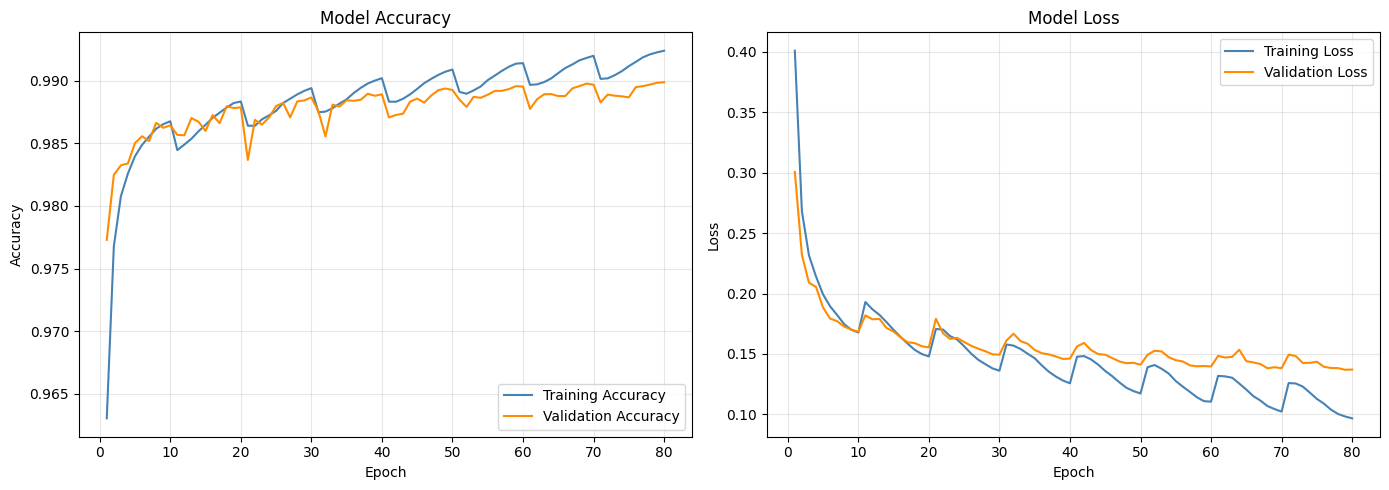

Plot saved to /kaggle/working/SwinUNet_history.png

--- Evaluating on Train Set ---
Total available train samples: 56788
Train: 4000 | Val: 1000

  TRAIN EVALUATION
  Loss       : 0.1347
  Dice       : 82.93%
  IoU        : 71.12%
  Pixel Acc  : 99.01%
  Accuracy   : 99.01%
  Precision  : 83.64%
  Recall     : 82.46%
  Specificity: 99.51%

--- Evaluating on Validation Set ---
Total available train samples: 56788
Train: 4000 | Val: 1000

  VALIDATION EVALUATION
  Loss       : 0.1318
  Dice       : 83.26%
  IoU        : 71.58%
  Pixel Acc  : 99.01%
  Accuracy   : 99.01%
  Precision  : 83.90%
  Recall     : 82.83%
  Specificity: 99.51%

--- Evaluating on Test Set ---
Total available test samples: 10364
Using test samples: 1000

  TEST EVALUATION
  Loss       : 0.1458
  Dice       : 81.64%
  IoU        : 69.22%
  Pixel Acc  : 98.89%
  Accuracy   : 98.89%
  Precision  : 84.02%
  Recall     : 79.73%
  Specificity: 99.51%

[FINAL RESULT] SwinUNet → Val Dice: 82.66% | Test IoU: 69.22%


In [2]:
import subprocess
subprocess.run(["pip", "install", "segmentation-models-pytorch", "einops", "-q"], check=True)

import os, glob, random
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms.functional as TF
from einops import rearrange

torch.manual_seed(42)
random.seed(42)
np.random.seed(42)

BASE_PATH     = "/kaggle/input/datasets/ahmadnafeestihami/brats2021-2d-slices"
TRAIN_IMG_DIR = os.path.join(BASE_PATH, "train/images")
TRAIN_MSK_DIR = os.path.join(BASE_PATH, "train/masks")
TEST_IMG_DIR  = os.path.join(BASE_PATH, "test/images")
TEST_MSK_DIR  = os.path.join(BASE_PATH, "test/masks")

N_TRAIN = 4000
N_VAL   = 1000
N_TEST  = 1000

CFG = dict(
    img_size     = 256,
    batch_size   = 8,
    lr           = 1e-4,
    weight_decay = 1e-5,
    epochs       = 80,
    patience     = 10,
    device       = "cuda" if torch.cuda.is_available() else "cpu",
)
print(f"Device : {CFG['device']}")
print(f"PyTorch: {torch.__version__}")


class BraTSDataset(Dataset):
    def __init__(self, img_paths, mask_paths, img_size=256, augment=False):
        self.img_paths  = img_paths
        self.mask_paths = mask_paths
        self.img_size   = img_size
        self.augment    = augment

    def __len__(self):
        return len(self.img_paths)

    def _load(self, path, gray=False):
        img = Image.open(path).convert("L" if gray else "RGB")
        return img.resize((self.img_size, self.img_size), Image.BILINEAR)

    def __getitem__(self, idx):
        img  = self._load(self.img_paths[idx])
        mask = self._load(self.mask_paths[idx], gray=True)
        if self.augment:
            if random.random() > 0.5: img, mask = TF.hflip(img), TF.hflip(mask)
            if random.random() > 0.5: img, mask = TF.vflip(img), TF.vflip(mask)
            angle = random.choice([0, 90, 180, 270])
            if angle:
                img  = TF.rotate(img,  angle)
                mask = TF.rotate(mask, angle)
            img = TF.adjust_brightness(img, random.uniform(0.8, 1.2))
            img = TF.adjust_contrast(img,   random.uniform(0.8, 1.2))
        img  = TF.to_tensor(img)
        img  = TF.normalize(img, [0.5]*3, [0.5]*3)
        mask = TF.to_tensor(mask)
        mask = (mask > 0.5).float()
        return img, mask


def get_loaders():
    all_img_paths  = sorted(glob.glob(os.path.join(TRAIN_IMG_DIR, "*")))
    all_mask_paths = sorted(glob.glob(os.path.join(TRAIN_MSK_DIR, "*")))
    assert len(all_img_paths) > 0, f"No images found at {TRAIN_IMG_DIR}"
    assert len(all_img_paths) == len(all_mask_paths), "Image/mask count mismatch!"
    print(f"Total available train samples: {len(all_img_paths)}")
    idx      = list(range(len(all_img_paths)))
    random.shuffle(idx)
    selected = idx[:N_TRAIN + N_VAL]
    t_idx    = selected[:N_TRAIN]
    v_idx    = selected[N_TRAIN:]
    train_ds = BraTSDataset([all_img_paths[i] for i in t_idx],
                             [all_mask_paths[i] for i in t_idx],
                             CFG["img_size"], augment=True)
    val_ds   = BraTSDataset([all_img_paths[i] for i in v_idx],
                             [all_mask_paths[i] for i in v_idx],
                             CFG["img_size"], augment=False)
    train_loader = DataLoader(train_ds, batch_size=CFG["batch_size"],
                              shuffle=True,  num_workers=2, pin_memory=True)
    val_loader   = DataLoader(val_ds,   batch_size=CFG["batch_size"],
                              shuffle=False, num_workers=2, pin_memory=True)
    print(f"Train: {len(train_ds)} | Val: {len(val_ds)}")
    return train_loader, val_loader


def get_test_loader():
    all_img_paths  = sorted(glob.glob(os.path.join(TEST_IMG_DIR, "*")))
    all_mask_paths = sorted(glob.glob(os.path.join(TEST_MSK_DIR, "*")))
    assert len(all_img_paths) > 0, f"No test images found at {TEST_IMG_DIR}"
    print(f"Total available test samples: {len(all_img_paths)}")
    idx          = list(range(len(all_img_paths)))
    random.shuffle(idx)
    selected_idx = idx[:N_TEST]
    test_ds = BraTSDataset([all_img_paths[i] for i in selected_idx],
                            [all_mask_paths[i] for i in selected_idx],
                            CFG["img_size"], augment=False)
    print(f"Using test samples: {len(test_ds)}")
    return DataLoader(test_ds, batch_size=CFG["batch_size"],
                      shuffle=False, num_workers=2, pin_memory=True)


class DiceBCELoss(nn.Module):
    def __init__(self, smooth=1.0):
        super().__init__()
        self.smooth = smooth
        self.bce    = nn.BCEWithLogitsLoss()

    def forward(self, logits, targets):
        bce   = self.bce(logits, targets)
        prob  = torch.sigmoid(logits)
        inter = (prob * targets).sum(dim=(2, 3))
        dice  = 1 - (2*inter + self.smooth) / (
                    prob.sum(dim=(2,3)) + targets.sum(dim=(2,3)) + self.smooth)
        return 0.5 * dice.mean() + 0.5 * bce


def compute_metrics(logits, masks, thresh=0.5):
    preds = (torch.sigmoid(logits) > thresh).float()
    inter = (preds * masks).sum()
    dice  = (2*inter + 1) / (preds.sum() + masks.sum() + 1)
    iou   = (inter + 1)   / (preds.sum() + masks.sum() - inter + 1)
    acc   = (preds == masks).float().mean()
    tp    = ((preds==1)&(masks==1)).sum().float()
    tn    = ((preds==0)&(masks==0)).sum().float()
    fp    = ((preds==1)&(masks==0)).sum().float()
    fn    = ((preds==0)&(masks==1)).sum().float()
    prec  = tp / (tp + fp + 1e-7)
    rec   = tp / (tp + fn + 1e-7)
    spec  = tn / (tn + fp + 1e-7)
    pixel_acc = (tp + tn) / (tp + tn + fp + fn + 1e-7)
    return dice.item(), iou.item(), acc.item(), prec.item(), rec.item(), spec.item(), pixel_acc.item()


def evaluate_split(model, loader, device, split_name):
    model.eval()
    criterion = DiceBCELoss()
    total_loss = 0.0
    v_dice = v_iou = v_acc = v_prec = v_rec = v_spec = v_pix = 0.0
    with torch.no_grad():
        for imgs, masks in loader:
            imgs, masks = imgs.to(device), masks.to(device)
            out = model(imgs)
            if out.shape[-2:] != masks.shape[-2:]:
                out = F.interpolate(out, size=masks.shape[-2:], mode='bilinear', align_corners=False)
            total_loss += criterion(out, masks).item()
            d, i, a, p, r, s, px = compute_metrics(out, masks)
            v_dice += d; v_iou += i; v_acc += a
            v_prec += p; v_rec += r; v_spec += s; v_pix += px
    n = len(loader)
    print(f"\n{'='*60}")
    print(f"  {split_name} EVALUATION")
    print(f"{'='*60}")
    print(f"  Loss       : {total_loss/n:.4f}")
    print(f"  Dice       : {v_dice/n*100:.2f}%")
    print(f"  IoU        : {v_iou/n*100:.2f}%")
    print(f"  Pixel Acc  : {v_pix/n*100:.2f}%")
    print(f"  Accuracy   : {v_acc/n*100:.2f}%")
    print(f"  Precision  : {v_prec/n*100:.2f}%")
    print(f"  Recall     : {v_rec/n*100:.2f}%")
    print(f"  Specificity: {v_spec/n*100:.2f}%")
    print(f"{'='*60}")
    return v_dice/n, v_iou/n


def plot_history(history, model_name):
    epochs = range(1, len(history["train_loss"]) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].plot(epochs, history["train_acc"], color='steelblue',  linewidth=1.5, label="Training Accuracy")
    axes[0].plot(epochs, history["val_acc"],   color='darkorange', linewidth=1.5, label="Validation Accuracy")
    axes[0].set_title("Model Accuracy")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Accuracy")
    axes[0].legend(loc="lower right")
    axes[0].grid(True, alpha=0.3)
    axes[1].plot(epochs, history["train_loss"], color='steelblue',  linewidth=1.5, label="Training Loss")
    axes[1].plot(epochs, history["val_loss"],   color='darkorange', linewidth=1.5, label="Validation Loss")
    axes[1].set_title("Model Loss")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Loss")
    axes[1].legend(loc="upper right")
    axes[1].grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(f"/kaggle/working/{model_name}_history.png", dpi=150)
    plt.show()
    print(f"Plot saved to /kaggle/working/{model_name}_history.png")


def window_partition(x, window_size):
    B, H, W, C = x.shape
    x = x.view(B, H // window_size, window_size, W // window_size, window_size, C)
    return x.permute(0, 1, 3, 2, 4, 5).contiguous().view(-1, window_size, window_size, C)


def window_reverse(windows, window_size, H, W):
    B = int(windows.shape[0] / (H * W / window_size / window_size))
    x = windows.view(B, H // window_size, W // window_size, window_size, window_size, -1)
    return x.permute(0, 1, 3, 2, 4, 5).contiguous().view(B, H, W, -1)


class WindowAttention(nn.Module):
    def __init__(self, dim, window_size, num_heads, qkv_bias=True, attn_drop=0.0, proj_drop=0.0):
        super().__init__()
        self.dim         = dim
        self.window_size = window_size
        self.num_heads   = num_heads
        self.scale       = (dim // num_heads) ** -0.5
        self.relative_position_bias_table = nn.Parameter(
            torch.zeros((2 * window_size - 1) * (2 * window_size - 1), num_heads))
        nn.init.trunc_normal_(self.relative_position_bias_table, std=0.02)
        coords_h = torch.arange(window_size)
        coords_w = torch.arange(window_size)
        coords   = torch.stack(torch.meshgrid(coords_h, coords_w, indexing="ij"))
        coords_flatten = torch.flatten(coords, 1)
        relative_coords = coords_flatten[:, :, None] - coords_flatten[:, None, :]
        relative_coords = relative_coords.permute(1, 2, 0).contiguous()
        relative_coords[:, :, 0] += window_size - 1
        relative_coords[:, :, 1] += window_size - 1
        relative_coords[:, :, 0] *= 2 * window_size - 1
        self.register_buffer("relative_position_index", relative_coords.sum(-1))
        self.qkv       = nn.Linear(dim, dim * 3, bias=qkv_bias)
        self.attn_drop = nn.Dropout(attn_drop)
        self.proj      = nn.Linear(dim, dim)
        self.proj_drop = nn.Dropout(proj_drop)
        self.softmax   = nn.Softmax(dim=-1)

    def forward(self, x, mask=None):
        B_, N, C = x.shape
        qkv = self.qkv(x).reshape(B_, N, 3, self.num_heads, C // self.num_heads).permute(2, 0, 3, 1, 4)
        q, k, v = qkv.unbind(0)
        attn = (q @ k.transpose(-2, -1)) * self.scale
        rpb  = self.relative_position_bias_table[self.relative_position_index.view(-1)].view(
            self.window_size * self.window_size, self.window_size * self.window_size, -1)
        attn = attn + rpb.permute(2, 0, 1).contiguous().unsqueeze(0)
        if mask is not None:
            nW   = mask.shape[0]
            attn = attn.view(B_ // nW, nW, self.num_heads, N, N) + mask.unsqueeze(1).unsqueeze(0)
            attn = attn.view(-1, self.num_heads, N, N)
        attn = self.attn_drop(self.softmax(attn))
        x    = (attn @ v).transpose(1, 2).reshape(B_, N, C)
        return self.proj_drop(self.proj(x))


class SwinTransformerBlock(nn.Module):
    def __init__(self, dim, num_heads, window_size=8, shift_size=0, mlp_ratio=4.0, drop=0.0, attn_drop=0.0):
        super().__init__()
        self.window_size = window_size
        self.shift_size  = shift_size
        self.norm1 = nn.LayerNorm(dim)
        self.attn  = WindowAttention(dim, window_size, num_heads, attn_drop=attn_drop, proj_drop=drop)
        self.norm2 = nn.LayerNorm(dim)
        self.mlp   = nn.Sequential(
            nn.Linear(dim, int(dim * mlp_ratio)),
            nn.GELU(),
            nn.Dropout(drop),
            nn.Linear(int(dim * mlp_ratio), dim),
            nn.Dropout(drop),
        )

    def forward(self, x, H, W, attn_mask=None):
        B, L, C  = x.shape
        shortcut = x
        x = self.norm1(x).view(B, H, W, C)
        if self.shift_size > 0:
            x = torch.roll(x, shifts=(-self.shift_size, -self.shift_size), dims=(1, 2))
        x_win  = window_partition(x, self.window_size).view(-1, self.window_size * self.window_size, C)
        x_win  = self.attn(x_win, mask=attn_mask)
        x_win  = x_win.view(-1, self.window_size, self.window_size, C)
        x      = window_reverse(x_win, self.window_size, H, W)
        if self.shift_size > 0:
            x = torch.roll(x, shifts=(self.shift_size, self.shift_size), dims=(1, 2))
        x = shortcut + x.view(B, H * W, C)
        x = x + self.mlp(self.norm2(x))
        return x


class PatchMerging(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.norm      = nn.LayerNorm(4 * dim)
        self.reduction = nn.Linear(4 * dim, 2 * dim, bias=False)

    def forward(self, x, H, W):
        B, L, C = x.shape
        x  = x.view(B, H, W, C)
        x0 = x[:, 0::2, 0::2, :]
        x1 = x[:, 1::2, 0::2, :]
        x2 = x[:, 0::2, 1::2, :]
        x3 = x[:, 1::2, 1::2, :]
        x  = self.reduction(self.norm(torch.cat([x0, x1, x2, x3], -1).view(B, -1, 4 * C)))
        return x


class PatchExpand(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.expand = nn.Linear(dim, 2 * dim, bias=False)
        self.norm   = nn.LayerNorm(dim // 2)

    def forward(self, x, H, W):
        x   = self.expand(x)
        B, L, C = x.shape
        x   = rearrange(x.view(B, H, W, C), 'b h w (p1 p2 c) -> b (h p1) (w p2) c', p1=2, p2=2, c=C // 4)
        return self.norm(x.view(B, -1, C // 4))


class FinalExpand(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.expand = nn.Linear(dim, 16 * dim, bias=False)
        self.norm   = nn.LayerNorm(dim)

    def forward(self, x, H, W):
        x   = self.expand(x)
        B, L, C = x.shape
        x   = rearrange(x.view(B, H, W, C), 'b h w (p1 p2 c) -> b (h p1) (w p2) c', p1=4, p2=4, c=C // 16)
        return self.norm(x.view(B, -1, C // 16))


class SwinEncoderStage(nn.Module):
    def __init__(self, dim, depth, num_heads, window_size=8, mlp_ratio=4.0, drop=0.0, attn_drop=0.0):
        super().__init__()
        self.blocks = nn.ModuleList([
            SwinTransformerBlock(dim, num_heads, window_size,
                                 shift_size=0 if i % 2 == 0 else window_size // 2,
                                 mlp_ratio=mlp_ratio, drop=drop, attn_drop=attn_drop)
            for i in range(depth)
        ])

    def _make_mask(self, H, W, window_size, shift_size, device):
        if shift_size == 0:
            return None
        img_mask = torch.zeros((1, H, W, 1), device=device)
        for i, hs in enumerate((slice(0, -window_size), slice(-window_size, -shift_size), slice(-shift_size, None))):
            for j, ws in enumerate((slice(0, -window_size), slice(-window_size, -shift_size), slice(-shift_size, None))):
                img_mask[:, hs, ws, :] = i * 3 + j
        mw   = window_partition(img_mask, window_size).view(-1, window_size * window_size)
        mask = mw.unsqueeze(1) - mw.unsqueeze(2)
        return mask.masked_fill(mask != 0, -100.0).masked_fill(mask == 0, 0.0)

    def forward(self, x, H, W):
        for blk in self.blocks:
            x = blk(x, H, W, self._make_mask(H, W, blk.window_size, blk.shift_size, x.device))
        return x


class SwinDecoderStage(nn.Module):
    def __init__(self, dim, depth, num_heads, window_size=8, mlp_ratio=4.0, drop=0.0, attn_drop=0.0):
        super().__init__()
        self.blocks = nn.ModuleList([
            SwinTransformerBlock(dim, num_heads, window_size,
                                 shift_size=0 if i % 2 == 0 else window_size // 2,
                                 mlp_ratio=mlp_ratio, drop=drop, attn_drop=attn_drop)
            for i in range(depth)
        ])

    def _make_mask(self, H, W, window_size, shift_size, device):
        if shift_size == 0:
            return None
        img_mask = torch.zeros((1, H, W, 1), device=device)
        for i, hs in enumerate((slice(0, -window_size), slice(-window_size, -shift_size), slice(-shift_size, None))):
            for j, ws in enumerate((slice(0, -window_size), slice(-window_size, -shift_size), slice(-shift_size, None))):
                img_mask[:, hs, ws, :] = i * 3 + j
        mw   = window_partition(img_mask, window_size).view(-1, window_size * window_size)
        mask = mw.unsqueeze(1) - mw.unsqueeze(2)
        return mask.masked_fill(mask != 0, -100.0).masked_fill(mask == 0, 0.0)

    def forward(self, x, H, W):
        for blk in self.blocks:
            x = blk(x, H, W, self._make_mask(H, W, blk.window_size, blk.shift_size, x.device))
        return x


class SwinUNet(nn.Module):
    def __init__(self, in_ch=3, num_classes=1, img_size=256, patch_size=4,
                 embed_dim=96, depths=(2, 2, 6, 2), num_heads=(3, 6, 12, 24),
                 window_size=8, mlp_ratio=4.0, drop_rate=0.0, attn_drop_rate=0.0):
        super().__init__()
        self.patch_size  = patch_size
        self.embed_dim   = embed_dim
        self.window_size = window_size
        ph = img_size // patch_size

        self.patch_embed = nn.Sequential(nn.Conv2d(in_ch, embed_dim, patch_size, stride=patch_size), nn.Flatten(2))
        self.patch_norm  = nn.LayerNorm(embed_dim)
        self.pos_drop    = nn.Dropout(drop_rate)

        self.enc1  = SwinEncoderStage(embed_dim,    depths[0], num_heads[0], window_size, mlp_ratio, drop_rate, attn_drop_rate)
        self.down1 = PatchMerging(embed_dim)
        self.enc2  = SwinEncoderStage(embed_dim*2,  depths[1], num_heads[1], window_size, mlp_ratio, drop_rate, attn_drop_rate)
        self.down2 = PatchMerging(embed_dim*2)
        self.enc3  = SwinEncoderStage(embed_dim*4,  depths[2], num_heads[2], window_size, mlp_ratio, drop_rate, attn_drop_rate)
        self.down3 = PatchMerging(embed_dim*4)
        self.bottleneck = SwinEncoderStage(embed_dim*8, depths[3], num_heads[3], window_size, mlp_ratio, drop_rate, attn_drop_rate)

        self.up3     = PatchExpand(embed_dim*8)
        self.concat3 = nn.Linear(embed_dim*8, embed_dim*4, bias=False)
        self.dec3    = SwinDecoderStage(embed_dim*4, depths[2], num_heads[2], window_size, mlp_ratio, drop_rate, attn_drop_rate)

        self.up2     = PatchExpand(embed_dim*4)
        self.concat2 = nn.Linear(embed_dim*4, embed_dim*2, bias=False)
        self.dec2    = SwinDecoderStage(embed_dim*2, depths[1], num_heads[1], window_size, mlp_ratio, drop_rate, attn_drop_rate)

        self.up1     = PatchExpand(embed_dim*2)
        self.concat1 = nn.Linear(embed_dim*2, embed_dim, bias=False)
        self.dec1    = SwinDecoderStage(embed_dim, depths[0], num_heads[0], window_size, mlp_ratio, drop_rate, attn_drop_rate)

        self.final_expand = FinalExpand(embed_dim)
        self.dropout      = nn.Dropout(0.3)
        self.head         = nn.Conv2d(embed_dim, num_classes, 1)

    def forward(self, x):
        B, C, H, W = x.shape
        ph = H // self.patch_size
        pw = W // self.patch_size
        x  = self.pos_drop(self.patch_norm(self.patch_embed(x).transpose(1, 2)))

        e1 = self.enc1(x, ph, pw)
        x  = self.down1(e1, ph, pw);  h2, w2 = ph // 2, pw // 2
        e2 = self.enc2(x, h2, w2)
        x  = self.down2(e2, h2, w2);  h3, w3 = h2 // 2, w2 // 2
        e3 = self.enc3(x, h3, w3)
        x  = self.down3(e3, h3, w3);  h4, w4 = h3 // 2, w3 // 2
        x  = self.bottleneck(x, h4, w4)

        x  = self.up3(x, h4, w4)
        x  = self.dec3(self.concat3(torch.cat([x, e3], dim=-1)), h3, w3)
        x  = self.up2(x, h3, w3)
        x  = self.dec2(self.concat2(torch.cat([x, e2], dim=-1)), h2, w2)
        x  = self.up1(x, h2, w2)
        x  = self.dec1(self.concat1(torch.cat([x, e1], dim=-1)), ph, pw)

        x  = self.final_expand(x, ph, pw)
        x  = x.view(B, H, W, self.embed_dim).permute(0, 3, 1, 2)
        return self.head(self.dropout(x))


def train_model(model, model_name):
    device = CFG["device"]
    model  = model.to(device)

    train_loader, val_loader = get_loaders()
    criterion = DiceBCELoss()
    optimizer = torch.optim.AdamW(model.parameters(),
                                  lr=CFG["lr"],
                                  weight_decay=CFG["weight_decay"])
    scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=10)

    best_dice, no_improve = 0.0, 0
    best_weights = None
    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

    n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"\n{'='*60}")
    print(f"  Model  : {model_name}")
    print(f"  Params : {n_params/1e6:.2f}M")
    print(f"  Device : {device}")
    print(f"{'='*60}")

    for epoch in range(1, CFG["epochs"] + 1):
        model.train()
        t_loss = 0.0
        t_acc  = 0.0
        for imgs, masks in train_loader:
            imgs, masks = imgs.to(device), masks.to(device)
            optimizer.zero_grad()
            out = model(imgs)
            if out.shape[-2:] != masks.shape[-2:]:
                out = F.interpolate(out, size=masks.shape[-2:], mode='bilinear', align_corners=False)
            loss = criterion(out, masks)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            t_loss += loss.item()
            _, _, a, _, _, _, _ = compute_metrics(out, masks)
            t_acc += a
        t_loss /= len(train_loader)
        t_acc  /= len(train_loader)

        model.eval()
        v_loss = 0.0
        v_dice = v_iou = v_acc = v_prec = v_rec = v_spec = v_pix = 0.0
        with torch.no_grad():
            for imgs, masks in val_loader:
                imgs, masks = imgs.to(device), masks.to(device)
                out = model(imgs)
                if out.shape[-2:] != masks.shape[-2:]:
                    out = F.interpolate(out, size=masks.shape[-2:], mode='bilinear', align_corners=False)
                v_loss += criterion(out, masks).item()
                d, i, a, p, r, s, px = compute_metrics(out, masks)
                v_dice += d; v_iou += i; v_acc += a
                v_prec += p; v_rec += r; v_spec += s; v_pix += px

        n = len(val_loader)
        v_loss /= n
        v_dice /= n; v_iou /= n; v_acc /= n
        v_prec /= n; v_rec /= n; v_spec /= n; v_pix /= n

        scheduler.step()
        history["train_loss"].append(t_loss)
        history["val_loss"].append(v_loss)
        history["train_acc"].append(t_acc)
        history["val_acc"].append(v_acc)

        if epoch % 10 == 0 or epoch == 1:
            print(f"  Ep {epoch:03d} | Loss:{t_loss:.4f} | "
                  f"Dice:{v_dice:.4f} | IoU:{v_iou:.4f} | "
                  f"PixAcc:{v_pix:.4f} | Acc:{v_acc:.4f} | "
                  f"Prec:{v_prec:.4f} | Rec:{v_rec:.4f} | Spec:{v_spec:.4f}")

        if v_dice > best_dice:
            best_dice    = v_dice
            best_weights = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            no_improve   = 0
        else:
            no_improve += 1
            if no_improve >= CFG["patience"]:
                print(f"  Early stop at epoch {epoch}.")
                break

    model.load_state_dict(best_weights)

    print(f"\n{'='*60}")
    print(f"  {model_name} TRAINING COMPLETE")
    print(f"  Best Val Dice : {best_dice*100:.2f}%")
    print(f"{'='*60}")

    plot_history(history, model_name)

    print("\n--- Evaluating on Train Set ---")
    train_loader_eval, _ = get_loaders()
    evaluate_split(model, train_loader_eval, device, "TRAIN")

    print("\n--- Evaluating on Validation Set ---")
    _, val_loader_eval = get_loaders()
    evaluate_split(model, val_loader_eval, device, "VALIDATION")

    print("\n--- Evaluating on Test Set ---")
    test_loader = get_test_loader()
    test_dice, test_iou = evaluate_split(model, test_loader, device, "TEST")

    return model, history, best_dice, test_iou


model_swinunet = SwinUNet(in_ch=3, num_classes=1, img_size=CFG["img_size"],
                          patch_size=4, embed_dim=96, depths=(2, 2, 6, 2),
                          num_heads=(3, 6, 12, 24), window_size=8)
model_swinunet, history_swinunet, dice_swinunet, iou_swinunet = train_model(model_swinunet, "SwinUNet")
print(f"\n[FINAL RESULT] SwinUNet → Val Dice: {dice_swinunet*100:.2f}% | Test IoU: {iou_swinunet*100:.2f}%")